In [9]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

RANDOM_STATE = 42


sns.set(style="whitegrid")


In [21]:
df = pd.read_csv('Data/CC GENERAL.csv')

In [22]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [24]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [26]:
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())

In [27]:
feature_names = df.columns.tolist()
# feature_names

In [28]:
df.isna().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [29]:
df.head(2)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.4,0.0,95.4,0.000000,0.166667,0.0,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.0,0.0,0.0,6442.945483,0.000000,0.0,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12


In [30]:
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

In [31]:
df = df.drop(columns=['CUST_ID'], axis=1)
df.shape

(8950, 17)

In [32]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

log_transform = FunctionTransformer(np.log1p, validate=False)

log_columns = [
    'BALANCE',
    'PURCHASES',
    'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE',
    'CREDIT_LIMIT',
    'PAYMENTS',
    'MINIMUM_PAYMENTS',
    'CASH_ADVANCE_TRX',
    'PURCHASES_TRX'
]

normal_columns =[
    'BALANCE_FREQUENCY',
    'PURCHASES_FREQUENCY',
    'ONEOFF_PURCHASES_FREQUENCY',
    'PURCHASES_INSTALLMENTS_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY',
    'PRC_FULL_PAYMENT',
    'TENURE'
]

In [33]:
log_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transform),
    ("scaler", RobustScaler())
])

normal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [34]:
processor = ColumnTransformer([
    ("log_features", log_pipeline, log_columns),  #made a change here:log_pipeline

    ("normal_features", normal_pipeline, normal_columns )
])

In [35]:
processor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_features', ...), ('normal_features', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name``

In [36]:
# numeric_features = [
#     'BALANCE',
#     'BALANCE_FREQUENCY',
#     'PURCHASES',
#     'ONEOFF_PURCHASES',
#     'INSTALLMENTS_PURCHASES',
#     'CASH_ADVANCE',
#     'PURCHASES_FREQUENCY',
#     'ONEOFF_PURCHASES_FREQUENCY',
#     'PURCHASES_INSTALLMENTS_FREQUENCY',
#     'CASH_ADVANCE_FREQUENCY',
#     'CASH_ADVANCE_TRX',
#     'PURCHASES_TRX',
#     'CREDIT_LIMIT',
#     'PAYMENTS',
#     'MINIMUM_PAYMENTS',
#     'PRC_FULL_PAYMENT',
#     'TENURE'
# ]


# preprocess_pca_pipeline = Pipeline([
#     ("preprocessor", processor),
#     # ("pca", PCA((n_components=n_comp_95,, random_state=42))
# ])

X_preprocess = processor.fit_transform(df)

Variance captured by just 2 components: 0.952


C:\Users\Saad\AppData\Local\Temp\ipykernel_19188\747309432.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], cmap="viridis", alpha=0.8, edgecolor="none")


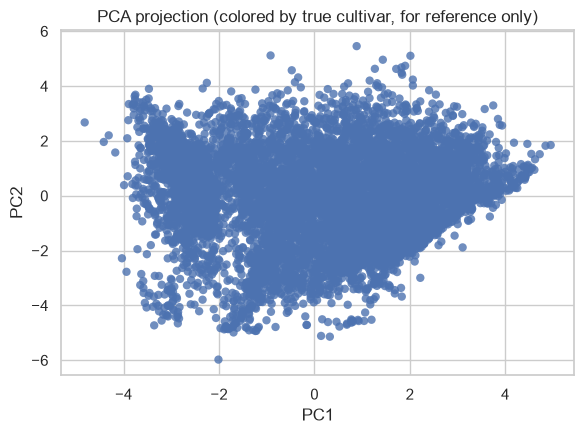

In [37]:
pca_2d = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X_preprocess)
print("Variance captured by just 2 components:", round(pca_2d.explained_variance_ratio_.sum(), 3))

fig, ax = plt.subplots(figsize=(6, 4.5))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], cmap="viridis", alpha=0.8, edgecolor="none")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA projection (colored by true cultivar, for reference only)")
plt.tight_layout()
plt.show()


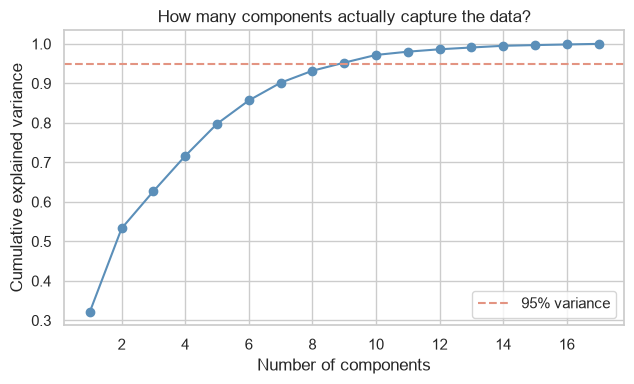

Components needed for 95% variance: 9 (out of 17)


In [38]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_preprocess)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(range(1, len(cum_var) + 1), cum_var, "o-", color="#5B8FB9")
ax.axhline(0.95, color="#E39482", linestyle="--", label="95% variance")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("How many components actually capture the data?")
ax.legend()
plt.tight_layout()
plt.show()

n_comp_95 = int(np.argmax(cum_var >= 0.95) + 1)
print(f"Components needed for 95% variance: {n_comp_95} (out of {df.shape[1]})")


C:\Users\Saad\AppData\Local\Temp\ipykernel_19188\2048390469.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], cmap="viridis", alpha=0.8, edgecolor="none")


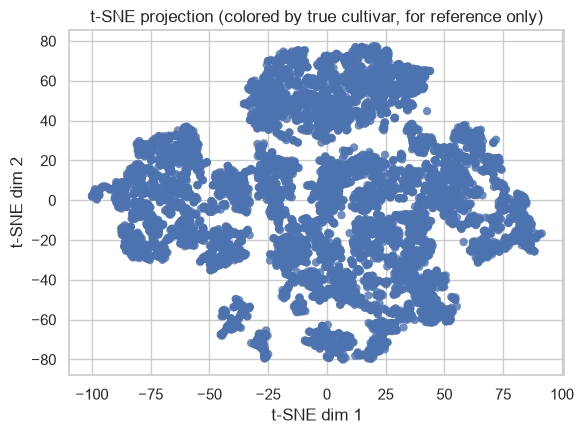

In [39]:
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init="pca")
X_tsne = tsne.fit_transform(X_preprocess)

fig, ax = plt.subplots(figsize=(6, 4.5))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], cmap="viridis", alpha=0.8, edgecolor="none")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.set_title("t-SNE projection (colored by true cultivar, for reference only)")
plt.tight_layout()
plt.show()


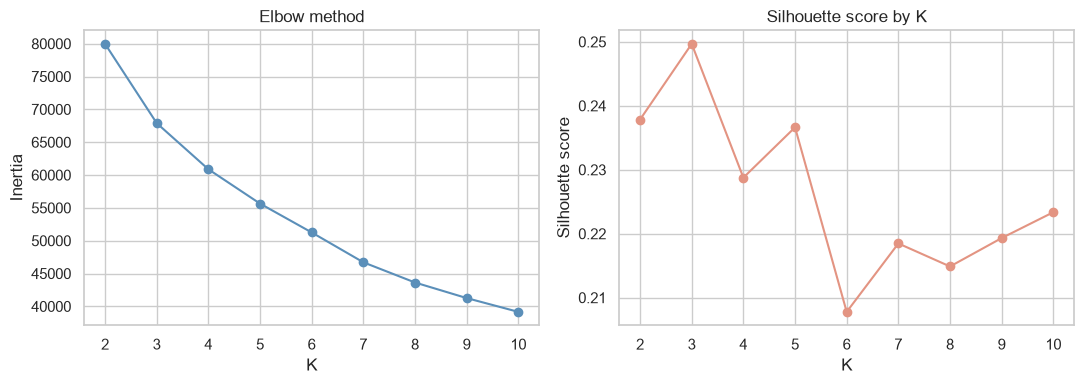

K with the highest silhouette score: 3


In [40]:
K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_preprocess)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_preprocess, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(K_range), inertias, "o-", color="#5B8FB9")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow method")

axes[1].plot(list(K_range), sil_scores, "o-", color="#E39482")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette score"); axes[1].set_title("Silhouette score by K")
plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print("K with the highest silhouette score:", best_k)


In [41]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_preprocess)

print("Silhouette score:", round(silhouette_score(X_preprocess, cluster_labels), 3))
# print("Adjusted Rand Index vs true labels:", round(adjusted_rand_score(y_true, cluster_labels), 3))
# print("Normalized Mutual Info vs true labels:", round(normalized_mutual_info_score(y_true, cluster_labels), 3))
print("Cluster sizes:", np.bincount(cluster_labels))


Silhouette score: 0.25
Cluster sizes: [3154 1617 4179]


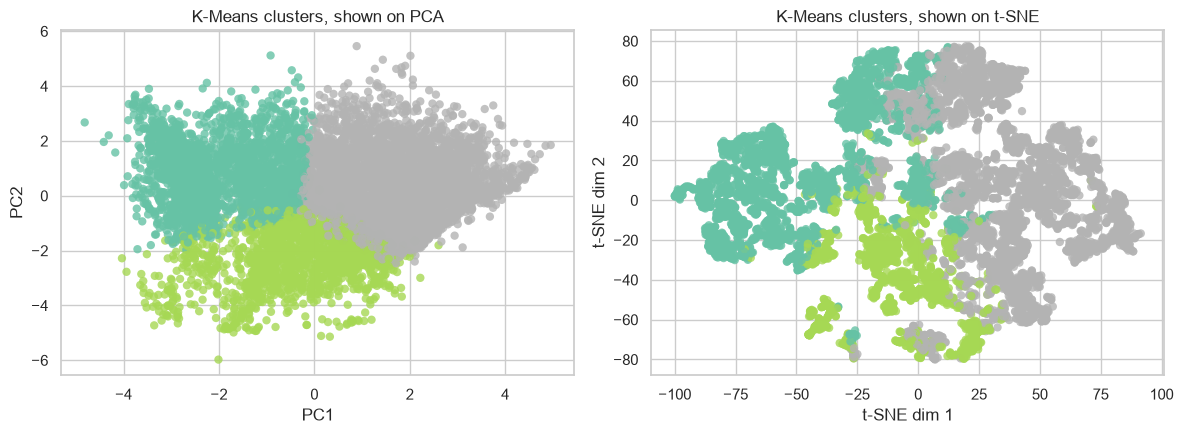

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="Set2", alpha=0.8, edgecolor="none")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].set_title("K-Means clusters, shown on PCA")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, cmap="Set2", alpha=0.8, edgecolor="none")
axes[1].set_xlabel("t-SNE dim 1"); axes[1].set_ylabel("t-SNE dim 2")
axes[1].set_title("K-Means clusters, shown on t-SNE")

plt.tight_layout()
plt.show()


In [45]:
preprocess_pca_pipeline = Pipeline([
    ("preprocessor", processor),
    ("pca", PCA(n_components=n_comp_95,random_state=42))
])

X_p95 = processor.fit_transform(df)

In [46]:
kmeans_pca = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
cluster_labels_pca = kmeans_pca.fit_predict(X_p95)

print(f"Clustering on {n_comp_95} PCA components (95% variance) instead of all 13 raw features:")
print("Silhouette score:", round(silhouette_score(X_p95, cluster_labels_pca), 3))
# print("Adjusted Rand Index vs true labels:", round(adjusted_rand_score(y_true, cluster_labels_pca), 3))


Clustering on 9 PCA components (95% variance) instead of all 13 raw features:
Silhouette score: 0.25
